# End-to-End Modeling Flow
1. Install dependencies
2. Load raw Excel data
3. Check nulls and duplicates
4. Clean and preprocess data
5. Encode categorical features
6. Train-test split and feature scaling
7. Train 3 models (Logistic Regression, Random Forest, XGBoost)
8. Evaluate and compare models
9. Analyze feature importance and churn probabilities

In [247]:
# from pathlib import Path
# import pandas as pd

# # Build path relative to this notebook: ml/model.ipynb -> data/raw/*.xlsx
# data_path = Path.cwd().parent / "data" / "raw" / "E Commerce Dataset.xlsx"
# if not data_path.exists():
#     raise FileNotFoundError(f"Dataset not found at: {data_path}")

# # Inspect workbook and choose the most likely data sheet (usually the one with most rows).
# xls = pd.ExcelFile(data_path)
# sheet_candidates = []
# for sheet in xls.sheet_names:
#     temp = pd.read_excel(data_path, sheet_name=sheet)
#     sheet_candidates.append((sheet, temp.shape[0], temp.shape[1]))

# sheet_summary = pd.DataFrame(sheet_candidates, columns=["sheet", "rows", "cols"])
# best_sheet = sheet_summary.sort_values(["rows", "cols"], ascending=False).iloc[0]["sheet"]
# print("Available sheets:")
# display(sheet_summary)
# print(f"Selected sheet for modeling: {best_sheet}")

# # Load selected data sheet
# df = pd.read_excel(data_path, sheet_name=best_sheet)
# print(f"Loaded data shape: {df.shape}")
# display(df.head())

# # -------- Preprocessing --------
# df_processed = df.copy()

# # 1) Drop fully empty rows/columns
# df_processed = df_processed.dropna(how="all").dropna(axis=1, how="all")

# # 2) Normalize column names
# df_processed.columns = (
#     df_processed.columns.astype(str)
#     .str.strip()
#     .str.lower()
#     .str.replace(r"[^a-z0-9]+", "_", regex=True)
#     .str.strip("_")
# )

# # 3) Remove duplicate rows
# df_processed = df_processed.drop_duplicates().reset_index(drop=True)

# # 4) Trim whitespace in text columns
# text_cols = df_processed.select_dtypes(include=["object", "string"]).columns
# for col in text_cols:
#     df_processed[col] = df_processed[col].astype("string").str.strip()
#     df_processed[col] = df_processed[col].replace({"": pd.NA})

# # 5) Fill missing values
# num_cols = df_processed.select_dtypes(include=["number"]).columns
# cat_cols = df_processed.select_dtypes(exclude=["number"]).columns

# for col in num_cols:
#     df_processed[col] = df_processed[col].fillna(df_processed[col].median())

# for col in cat_cols:
#     mode_values = df_processed[col].mode(dropna=True)
#     if not mode_values.empty:
#         df_processed[col] = df_processed[col].fillna(mode_values.iloc[0])

# print(f"Processed data shape: {df_processed.shape}")
# print("Top missing-value counts after preprocessing:")
# display(df_processed.isna().sum().sort_values(ascending=False).head(10))

# display(df_processed.head())

In [248]:
from pathlib import Path
import pandas as pd

df = pd.read_csv(r"C:\Users\91940\Desktop\Kenexai raw\data\raw\churn_data_preprocessed.csv")

# -------- Preprocessing --------
df_processed = df.copy()

# 1) Drop fully empty rows/columns
df_processed = df_processed.dropna(how="all").dropna(axis=1, how="all")

# 2) Normalize column names
df_processed.columns = (
    df_processed.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# 3) Remove duplicate rows
df_processed = df_processed.drop_duplicates().reset_index(drop=True)

# 4) Trim whitespace in text columns
text_cols = df_processed.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    df_processed[col] = df_processed[col].astype("string").str.strip()
    df_processed[col] = df_processed[col].replace({"": pd.NA})

# 5) Fill missing values
num_cols = df_processed.select_dtypes(include=["number"]).columns
cat_cols = df_processed.select_dtypes(exclude=["number"]).columns

for col in num_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

for col in cat_cols:
    mode_values = df_processed[col].mode(dropna=True)
    if not mode_values.empty:
        df_processed[col] = df_processed[col].fillna(mode_values.iloc[0])

print(f"Processed data shape: {df_processed.shape}")
print("Top missing-value counts after preprocessing:")
display(df_processed.isna().sum().sort_values(ascending=False).head(10))

display(df_processed.head())

Processed data shape: (5630, 20)
Top missing-value counts after preprocessing:


customerid                  0
churn                       0
tenure                      0
preferredlogindevice        0
citytier                    0
warehousetohome             0
preferredpaymentmode        0
gender                      0
hourspendonapp              0
numberofdeviceregistered    0
dtype: int64

,customerid,churn,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [249]:
# Class balance check on processed target
if "df_processed" not in globals():
    raise NameError("Run preprocessing cell first.")

target_for_check = "churn" if "churn" in df_processed.columns else None
if target_for_check is None:
    raise KeyError("Target column 'churn' not found in df_processed.")

class_counts = df_processed[target_for_check].value_counts().sort_index()
class_proportions = (df_processed[target_for_check].value_counts(normalize=True) * 100).sort_index()

print("Class Counts:")
display(class_counts)
print("Class Proportions (%):")
display(class_proportions.round(2))

Class Counts:


churn
0    4682
1     948
Name: count, dtype: int64

Class Proportions (%):


churn
0    83.16
1    16.84
Name: proportion, dtype: float64

In [250]:
# Null and duplicate analysis on raw data
print("Null values per column (raw):")
display(df.isna().sum().sort_values(ascending=False))

duplicate_count = df.duplicated().sum()
print(f"Duplicate rows (raw): {duplicate_count}")

Null values per column (raw):


CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Duplicate rows (raw): 0


In [251]:
# Clean data: remove duplicates, then handle nulls
df_processed = df.copy()

# 1) Remove fully empty rows/columns
df_processed = df_processed.dropna(how="all").dropna(axis=1, how="all")

# 2) Standardize column names
df_processed.columns = (
    df_processed.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# 3) Remove duplicate rows
before_rows = len(df_processed)
df_processed = df_processed.drop_duplicates().reset_index(drop=True)
after_rows = len(df_processed)
print(f"Removed duplicate rows: {before_rows - after_rows}")

# 4) Fill nulls
num_cols = df_processed.select_dtypes(include=["number"]).columns
cat_cols = df_processed.select_dtypes(exclude=["number"]).columns

for col in num_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())

for col in cat_cols:
    mode_values = df_processed[col].mode(dropna=True)
    if not mode_values.empty:
        df_processed[col] = df_processed[col].fillna(mode_values.iloc[0])

print(f"Processed data shape: {df_processed.shape}")
print("Null values per column (processed):")
display(df_processed.isna().sum().sort_values(ascending=False))
display(df_processed.head())

Removed duplicate rows: 0
Processed data shape: (5630, 20)
Null values per column (processed):


customerid                     0
churn                          0
tenure                         0
preferredlogindevice           0
citytier                       0
warehousetohome                0
preferredpaymentmode           0
gender                         0
hourspendonapp                 0
numberofdeviceregistered       0
preferedordercat               0
satisfactionscore              0
maritalstatus                  0
numberofaddress                0
complain                       0
orderamounthikefromlastyear    0
couponused                     0
ordercount                     0
daysincelastorder              0
cashbackamount                 0
dtype: int64

,customerid,churn,tenure,preferredlogindevice,citytier,warehousetohome,preferredpaymentmode,gender,hourspendonapp,numberofdeviceregistered,preferedordercat,satisfactionscore,maritalstatus,numberofaddress,complain,orderamounthikefromlastyear,couponused,ordercount,daysincelastorder,cashbackamount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [252]:
# Feature Encoding
if "df_processed" not in globals():
    raise NameError("df_processed not found. Run the preprocessing cells first.")

target_col = "churn" if "churn" in df_processed.columns else None
categorical_cols = df_processed.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Categorical columns to encode: {len(categorical_cols)}")
print(categorical_cols)

df_encoded = pd.get_dummies(
    df_processed,
    columns=categorical_cols,
    drop_first=True,
    dtype="int64"
 )

print(f"Original columns: {df_processed.shape[1]}")
print(f"Encoded columns: {df_encoded.shape[1]}")

if target_col and target_col in df_encoded.columns:
    X = df_encoded.drop(columns=[target_col])
    y = df_encoded[target_col].astype(int)
    print(f"X shape: {X.shape}")
    print(f"y shape: {y.shape}")
else:
    X = df_encoded.copy()
    y = None
    print("Target column 'churn' not found; created only encoded feature matrix X.")

display(df_encoded.head())

Categorical columns to encode: 5
['preferredlogindevice', 'preferredpaymentmode', 'gender', 'preferedordercat', 'maritalstatus']
Original columns: 20
Encoded columns: 31
X shape: (5630, 30)
y shape: (5630,)


,customerid,churn,tenure,citytier,warehousetohome,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,...,preferredpaymentmode_E wallet,preferredpaymentmode_UPI,gender_Male,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others,maritalstatus_Married,maritalstatus_Single
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,0,0,0,0,1,0,0,0,0,1
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,0,1,1,0,0,1,0,0,0,1
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,0,0,1,0,0,1,0,0,0,1
3,50004,1,0.0,3,15.0,2.0,4,5,8,0,...,0,0,1,0,1,0,0,0,0,1
4,50005,1,0.0,1,12.0,3.0,3,5,3,0,...,0,0,1,0,0,1,0,0,0,1


In [253]:
# Train-test split and feature scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

if "X" not in globals() or "y" not in globals() or y is None:
    raise NameError("X and y not found. Run the feature encoding cell first.")

# 1) Split data (stratify for classification balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
 )

# 2) Scale features using training data only (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
 )
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
 )

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

display(X_train_scaled.head())

X_train shape: (4504, 30)
X_test shape: (1126, 30)
y_train shape: (4504,)
y_test shape: (1126,)


,customerid,tenure,citytier,warehousetohome,hourspendonapp,numberofdeviceregistered,satisfactionscore,numberofaddress,complain,orderamounthikefromlastyear,...,preferredpaymentmode_E wallet,preferredpaymentmode_UPI,gender_Male,preferedordercat_Grocery,preferedordercat_Laptop & Accessory,preferedordercat_Mobile,preferedordercat_Mobile Phone,preferedordercat_Others,maritalstatus_Married,maritalstatus_Single
1787,-0.633055,-0.135398,1.453559,0.043177,-1.325711,-0.675976,-1.493573,-0.856755,-0.623912,-0.468858,...,-0.357734,-0.282554,0.822705,-0.281178,-0.755632,-0.407719,-0.537306,-0.21837,-1.073282,1.468425
2147,-0.411598,-0.494759,1.453559,-0.318966,-2.742656,-0.675976,0.673881,-1.246653,-0.623912,0.366481,...,-0.357734,-0.282554,-1.215503,-0.281178,1.323395,-0.407719,-0.537306,-0.21837,0.931721,-0.681002
1717,-0.676117,-0.255185,-0.724000,-0.077537,0.091233,0.294877,0.673881,2.262432,-0.623912,0.923374,...,-0.357734,-0.282554,0.822705,-0.281178,1.323395,-0.407719,-0.537306,-0.21837,-1.073282,1.468425
2292,-0.322400,0.583322,1.453559,-0.560394,0.091233,-0.675976,0.673881,2.262432,1.602791,0.923374,...,-0.357734,-0.282554,0.822705,-0.281178,-0.755632,-0.407719,-0.537306,-0.21837,-1.073282,1.468425
5578,1.699011,0.223962,-0.724000,-0.318966,1.508178,1.265730,-0.048604,-0.076958,-0.623912,-1.025752,...,-0.357734,-0.282554,0.822705,-0.281178,1.323395,-0.407719,-0.537306,-0.21837,0.931721,-0.681002


In [254]:
# Imbalance check and handling setup (train split only)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

if "y_train" not in globals():
    raise NameError("Run train-test split cell first.")

train_class_counts = y_train.value_counts().sort_index()
majority_count = train_class_counts.max()
minority_count = train_class_counts.min()
imbalance_ratio = majority_count / minority_count if minority_count > 0 else np.inf

# Rule of thumb: ratio >= 1.5 indicates meaningful imbalance.
is_imbalanced = imbalance_ratio >= 1.5

print("Training class distribution:")
display(train_class_counts)
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")
print(f"Imbalanced: {is_imbalanced}")

if is_imbalanced:
    classes = np.array(sorted(y_train.unique()))
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}

    neg_count = int(train_class_counts.get(0, 0))
    pos_count = int(train_class_counts.get(1, 0))
    scale_pos_weight = (neg_count / pos_count) if pos_count > 0 else 1.0

    print("Applied class weights:")
    display(class_weight_dict)
    print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.4f}")
else:
    class_weight_dict = None
    scale_pos_weight = 1.0
    print("No imbalance handling needed; using default model weights.")

Training class distribution:


churn
0    3746
1     758
Name: count, dtype: int64

Imbalance ratio (majority/minority): 4.94
Imbalanced: True
Applied class weights:


{0: 0.601174586225307, 1: 2.970976253298153}

scale_pos_weight for XGBoost: 4.9420


# Model Training and Evaluation
Train Logistic Regression, Random Forest, and XGBoost, then compare metrics.

In [255]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42,
    class_weight=class_weight_dict if "class_weight_dict" in globals() and class_weight_dict is not None else None
 )
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [256]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=class_weight_dict if "class_weight_dict" in globals() and class_weight_dict is not None else None
 )
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [257]:
# Model 3: XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.06,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight if "scale_pos_weight" in globals() else 1.0
 )
xgb_model.fit(X_train, y_train)

print("XGBoost trained successfully.")

XGBoost trained successfully.


In [258]:
# Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

if "X_test" not in globals() or "X_test_scaled" not in globals() or "y_test" not in globals():
    raise NameError("Run preprocessing, encoding, and split/scaling cells first.")

models = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
}

results = []
for model_name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
    })

    print(f"\n{model_name} - Classification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(results_df)


Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       0.96      0.79      0.86       936
           1       0.44      0.84      0.58       190

    accuracy                           0.79      1126
   macro avg       0.70      0.81      0.72      1126
weighted avg       0.87      0.79      0.82      1126


Random Forest - Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       936
           1       0.97      0.78      0.87       190

    accuracy                           0.96      1126
   macro avg       0.97      0.89      0.92      1126
weighted avg       0.96      0.96      0.96      1126


XGBoost - Classification Report
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       936
           1       0.89      0.98      0.93       190

    accuracy                           0.98      1126
   macro av

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest,0.960036,0.973856,0.784211,0.868805,0.996547
1,XGBoost,0.975133,0.885714,0.978947,0.930000,0.995423
2,Logistic Regression,0.793961,0.441667,0.836842,0.578182,0.886314


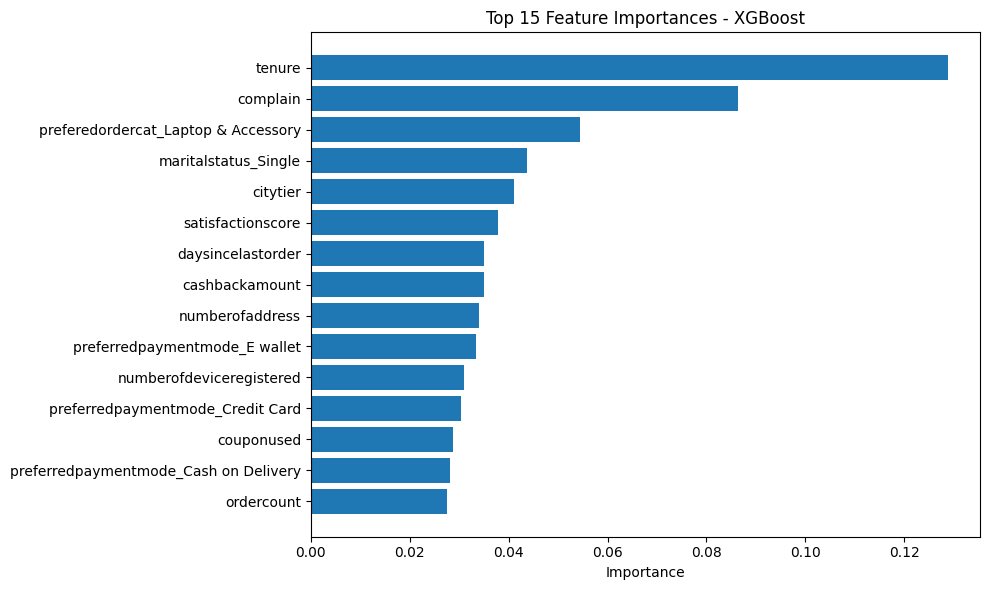

,feature,importance
1,tenure,0.128870
8,complain,0.086427
24,preferedordercat_Laptop & Accessory,0.054522
29,maritalstatus_Single,0.043781
2,citytier,0.041142
6,satisfactionscore,0.037797
12,daysincelastorder,0.035079
13,cashbackamount,0.035004
7,numberofaddress,0.033981
20,preferredpaymentmode_E wallet,0.033397


In [259]:
# Feature importance (XGBoost)
import matplotlib.pyplot as plt

if "xgb_model" not in globals() or "X" not in globals():
    raise NameError("Run model training cells first.")

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

display(importance_df)

In [260]:
# Customer segmentation with KMeans (optional analysis)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_scaled)

X_train_clustered = X_train_scaled.copy()
X_train_clustered["cluster"] = clusters

print("Cluster distribution (train):")
display(X_train_clustered["cluster"].value_counts().sort_index())

Cluster distribution (train):


cluster
0     625
1     673
2    2195
3    1011
Name: count, dtype: int64

In [261]:
# Preview clustered training data
display(X_train_clustered[["cluster"]].head(10))

,cluster
1787,2
2147,2
1717,2
2292,2
5578,2
1150,0
279,2
3151,2
753,2
1364,3


In [262]:
# Churn probability scoring on test set
if "xgb_model" not in globals() or "X_test" not in globals():
    raise NameError("Run model training and split cells first.")

churn_prob = xgb_model.predict_proba(X_test)[:, 1]
scored_test = pd.DataFrame({
    "index": X_test.index,
    "churn_probability": churn_prob
})

print("Top 10 highest-risk customers in test set:")
display(scored_test.sample(10))

Top 10 highest-risk customers in test set:


,index,churn_probability
319,5430,0.204738
439,1903,0.004643
629,2557,0.015104
910,5406,0.849558
236,5472,0.877769
765,1520,0.004101
920,5035,0.015151
620,764,0.736841
134,3555,0.044870
759,752,0.014174


Background sample shape: (500, 30)
Explain sample shape: (300, 30)


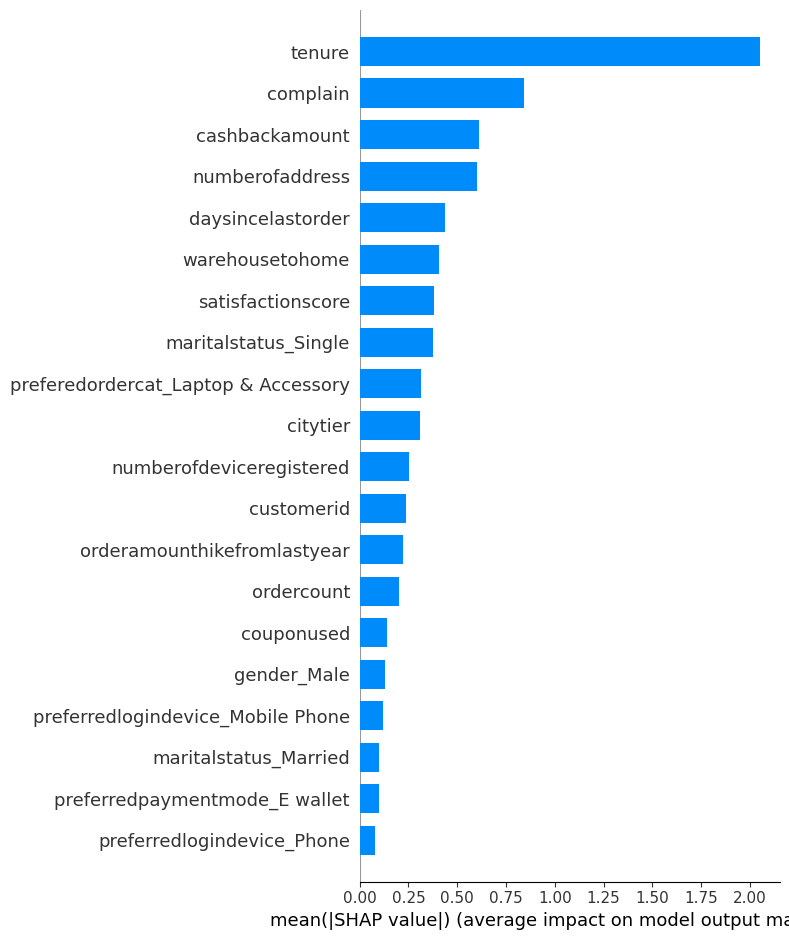

,feature,mean_abs_shap
1,tenure,2.052147
8,complain,0.843944
13,cashbackamount,0.612713
7,numberofaddress,0.602733
12,daysincelastorder,0.436230
3,warehousetohome,0.404346
6,satisfactionscore,0.378892
29,maritalstatus_Single,0.374525
24,preferedordercat_Laptop & Accessory,0.316408
2,citytier,0.311342


In [263]:
# SHAP explainability for XGBoost
import shap
import matplotlib.pyplot as plt

if "xgb_model" not in globals() or "X_train" not in globals() or "X_test" not in globals():
    raise NameError("Run the model training and split cells first.")

# Use a sample to keep SHAP computation fast and readable.
X_background = X_train.sample(n=min(500, len(X_train)), random_state=42)
X_explain = X_test.sample(n=min(300, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_explain)

print(f"Background sample shape: {X_background.shape}")
print(f"Explain sample shape: {X_explain.shape}")

# Global importance (bar)
plt.figure()
shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.tight_layout()
plt.show()


# Top features by mean absolute SHAP
shap_importance = pd.DataFrame({
    "feature": X_explain.columns,
    "mean_abs_shap": abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance.head(15))

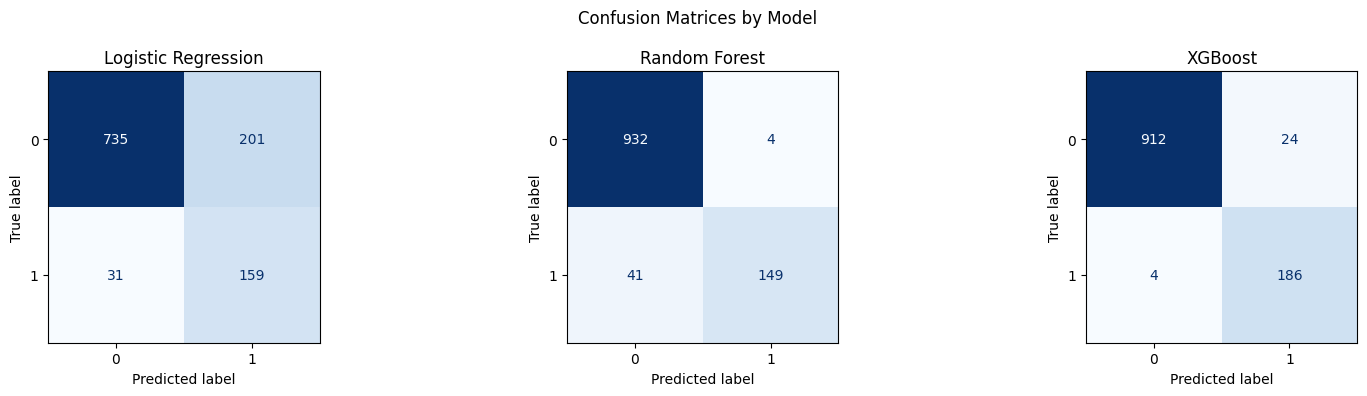

In [265]:
# Confusion Matrix (all models)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if "y_test" not in globals():
    raise NameError("Run model training and evaluation cells first.")

model_inputs = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, (mdl, x_eval)) in zip(axes, model_inputs.items()):
    y_pred_cm = mdl.predict(x_eval)
    cm = confusion_matrix(y_test, y_pred_cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name)

plt.suptitle("Confusion Matrices by Model")
plt.tight_layout()
plt.show()